In [2]:
import pandas as pd

df = pd.read_csv('cars.csv')
df.head()


,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa
4,ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa


https://www.kaggle.com/datasets/tawfikelmetwally/automobile-dataset

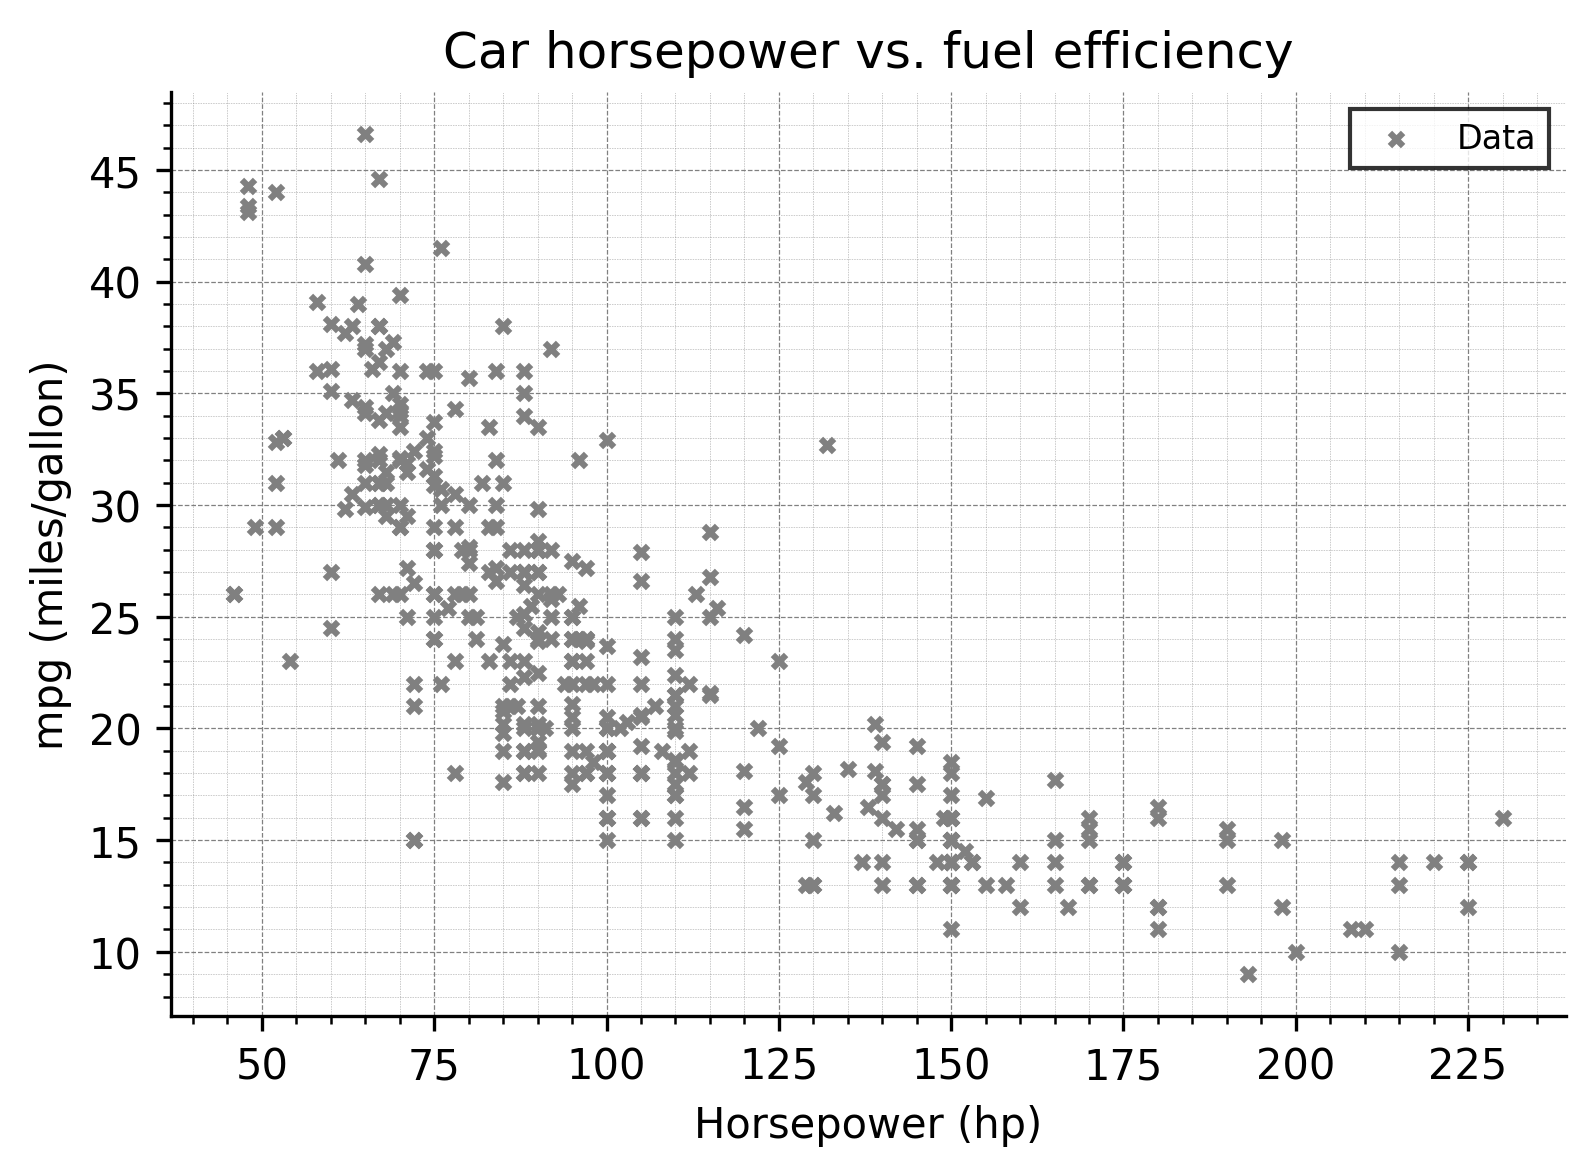

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 4), dpi=300)

# Major and Minor Ticks
plt.minorticks_on()

# Grid settings to mimic LaTeX style
plt.grid(which='both', linestyle='--', linewidth='0.30', color='gray')
plt.grid(which='minor', linestyle=':', linewidth='0.15', color='gray')

# Remove top and right spines to mimic LaTeX/pgfplots style
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=10)

plt.scatter(df['horsepower'], df['mpg'], label='Data', marker='x', color='grey', s=10)
plt.xlabel('Horsepower (hp)')
plt.ylabel('mpg (miles/gallon)')
plt.title('Car horsepower vs. fuel efficiency')

# legend
plt.legend(fontsize=8, edgecolor='black', facecolor='white', framealpha=0.8, fancybox=False)

plt.show()

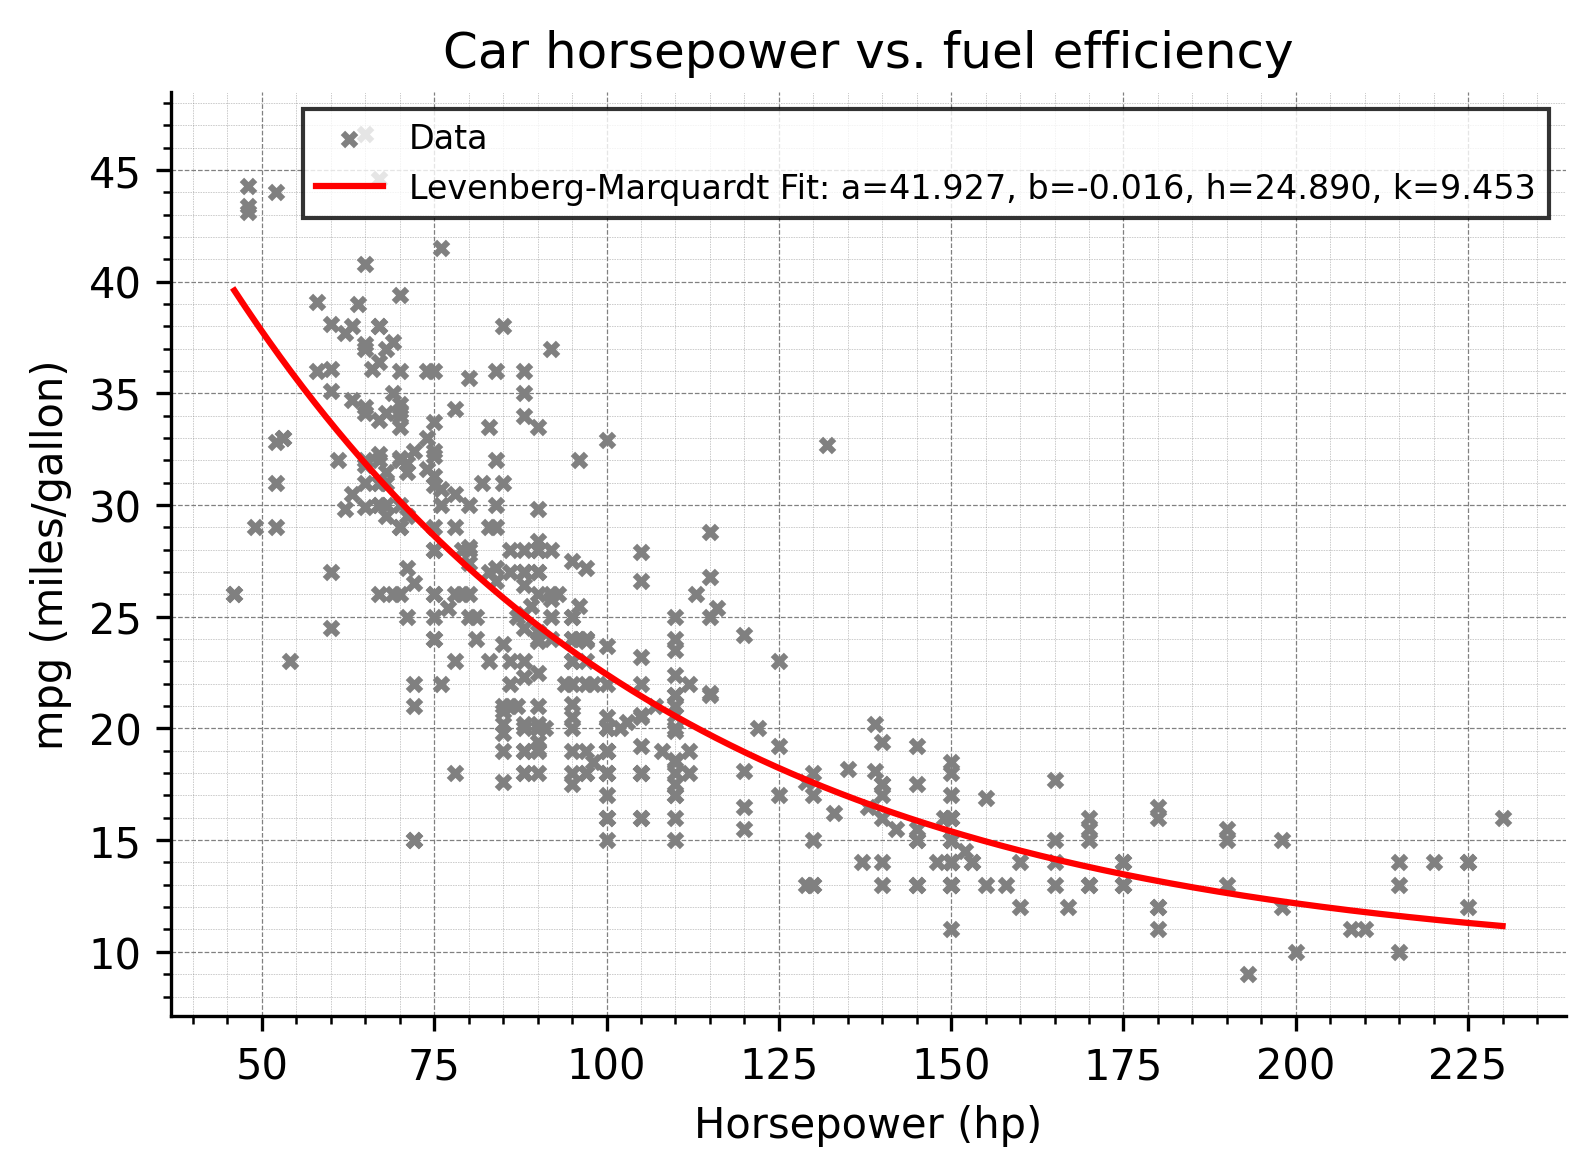

In [4]:
from scipy.optimize import curve_fit

# Define the exponential function to fit
def exp(x, a, b, h, k):
    return a * np.e**(b * (x - h)) + k

# Initial parameter guess
p0 = [5, -0.05, 90, 12]

# check for non-finite values (NaN, Inf) in the dataset
non_finite_values = df[['horsepower', 'mpg']].isnull().values.any()

# if non-finite values are found, we will clean the dataset
if non_finite_values:
    # remove rows with non-finite values
    df_clean = df.dropna(subset=['horsepower', 'mpg'])
else:
    # if there are no non-finite values, we will proceed with the current dataset
    df_clean = df

# try the curve fit without bounds on the cleaned data
popt, pcov = curve_fit(exp, df_clean['horsepower'], df_clean['mpg'], p0=p0)

# check if the covariance matrix was estimated successfully
if np.any(np.isinf(np.sqrt(np.diag(pcov)))):
    # if the unbounded fit also failed, we will try fitting with bounds and cleaned data.
    
    # define bounds within reasonable ranges based on the data
    bounds = ([0, -np.inf, df_clean['horsepower'].min(), 0], 
              [np.inf, 0, df_clean['horsepower'].max(), np.inf])
    
    # try the curve fit with bounds on the cleaned data
    popt_bound, pcov_bound = curve_fit(exp, df_clean['horsepower'], df_clean['mpg'], p0=p0, bounds=bounds)
    
    # check if this fit was successful
    if np.any(np.isinf(np.sqrt(np.diag(pcov_bound)))):
        # if the bounded fit also failed, we may need to try a different model or transformation.
        fit_success = False
    else:
        fit_success = True
        popt = popt_bound
        pcov = pcov_bound
else:
    # if the unbounded fit was successful, we will use these parameters.
    fit_success = True

# output the result of the fitting process
fit_success, popt, pcov

# create a high-resolution array of x values for a smooth curve
x_high_res = np.linspace(df_clean['horsepower'].min(), df_clean['horsepower'].max(), 1000)
# calculate the fitted y values using the high-resolution x values
y_fitted = exp(x_high_res, *popt)

# plot the original data and the fitted curve
plt.figure(figsize=(6, 4), dpi=300)
ax = plt.gca()

# gridlines/ticks
plt.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=10)
plt.grid(which='both', linestyle='--', linewidth='0.30', color='gray')
plt.grid(which='minor', linestyle=':', linewidth='0.15', color='gray')

# remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.scatter(df_clean['horsepower'], df_clean['mpg'], label='Data', marker='x', color='grey', s=10)
plt.plot(x_high_res, y_fitted, 'r-', label='Levenberg-Marquardt Fit: a=%5.3f, b=%5.3f, h=%5.3f, k=%5.3f' % tuple(popt))

plt.xlabel('Horsepower (hp)')
plt.ylabel('mpg (miles/gallon)')
plt.title('Car horsepower vs. fuel efficiency')

plt.legend(fontsize=8, edgecolor='black', facecolor='white', framealpha=0.8, fancybox=False)

plt.show()

Running gradient descent...


100%|██████████| 50000/50000 [00:36<00:00, 1382.90it/s]


REPORT: Iteration 0: a=50.0000, b=-0.0880, h=1.0000, k=1.0000, Loss=218298.4811
REPORT: Iteration 10000: a=50.0021, b=-0.0208, h=1.0075, k=1.0452, Loss=135072.5889
REPORT: Iteration 20000: a=50.0041, b=-0.0245, h=1.0148, k=1.0870, Loss=35210.6284
REPORT: Iteration 30000: a=50.0062, b=-0.0259, h=1.0228, k=1.1331, Loss=38596.4116
REPORT: Iteration 40000: a=50.0087, b=-0.0139, h=1.0323, k=1.1897, Loss=13423.9783
REPORT: Iteration 50000: a=50.0106, b=-0.0093, h=1.0389, k=1.2265, Loss=70446.1865


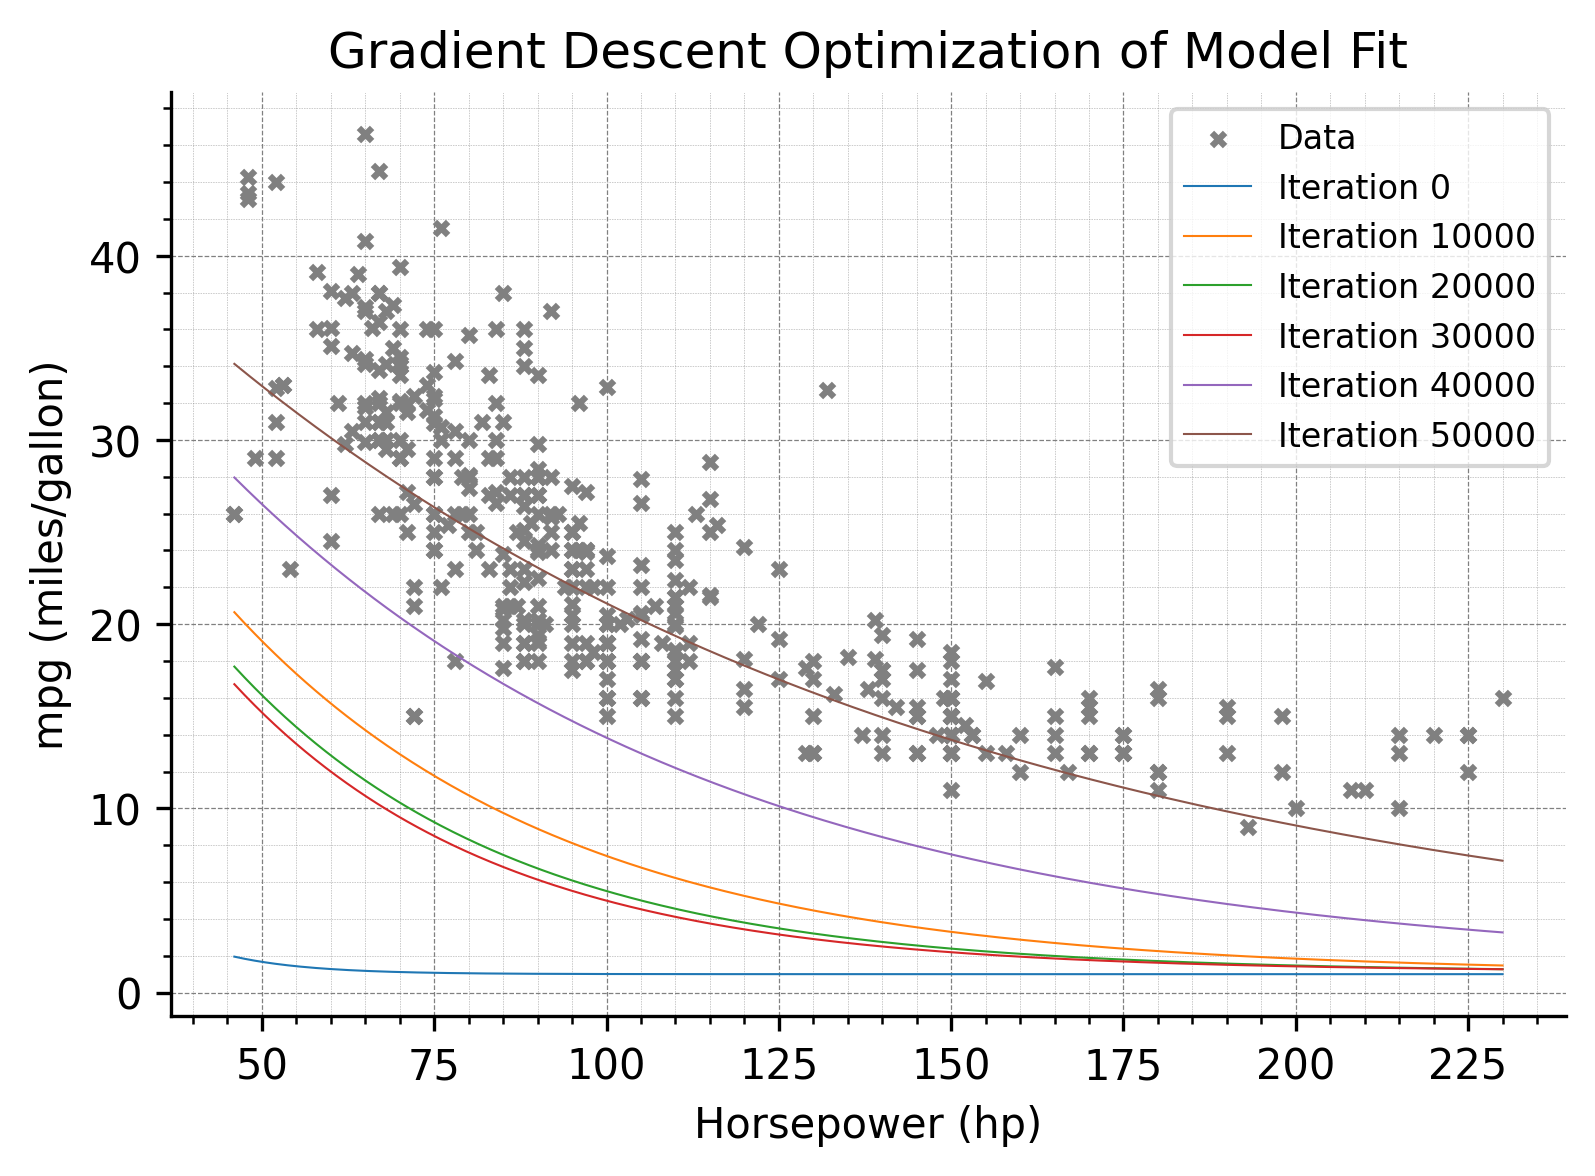

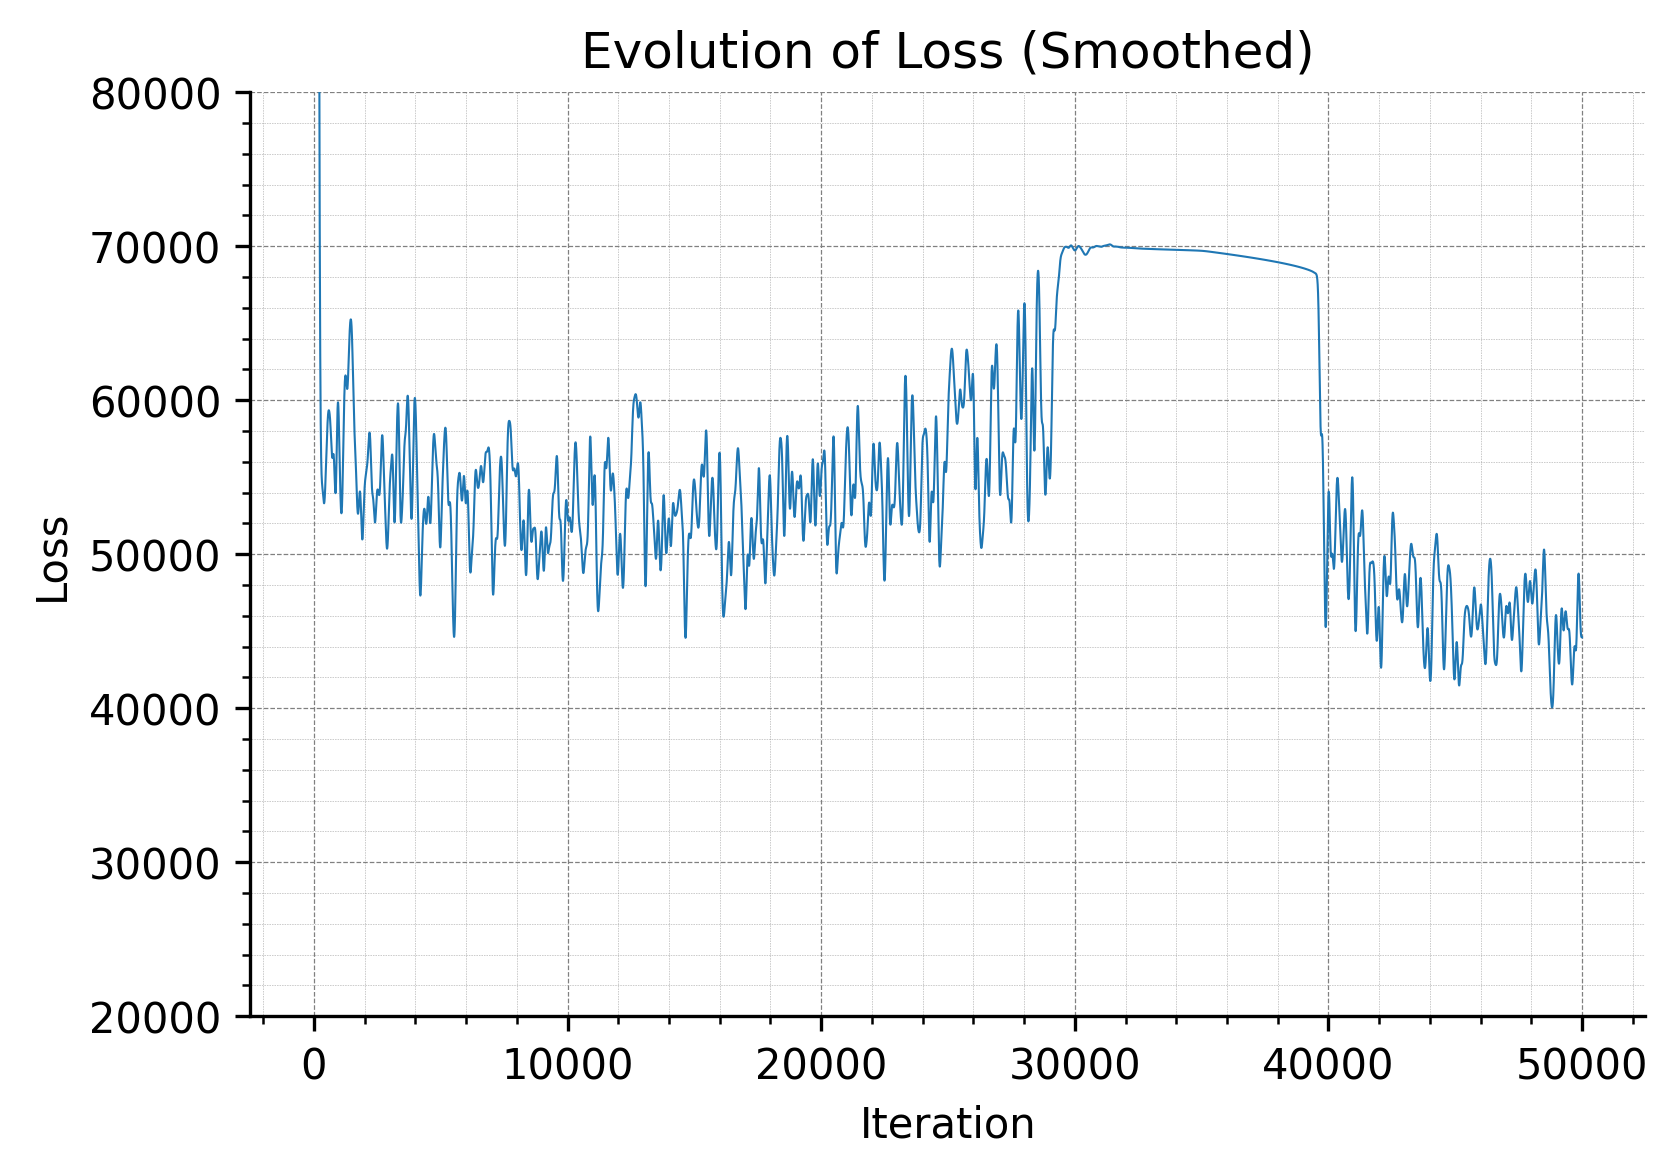

In [9]:
from tqdm import tqdm

def gradient_descent(x, y, p0, learning_rate, num_iterations, max_step=0.1):
    # Initialize parameters
    a, b, h, k = p0
    
    # Store the parameter updates
    param_evolution = []
    loss_evolution = []
    
    # Exponential model function
    def model(x, a, b, h, k):
        return a * np.exp(b * (x - h)) + k
    
    # Loss function: sum of squared residuals
    def loss(y, y_pred):
        return np.sum((y - y_pred) ** 2)
    
    # Begin iterations
    for iteration in tqdm(range(num_iterations)):
        # Predicted y values from the current parameter set
        y_pred = model(x, a, b, h, k)
        
        # Calculate the loss
        current_loss = loss(y, y_pred)
        
        # Calculate the gradients for each parameter
        grad_a = -2 * np.sum((y - y_pred) * np.exp(b * (x - h)))
        grad_b = -2 * np.sum((y - y_pred) * a * (x - h) * np.exp(b * (x - h)))
        grad_h = 2 * np.sum((y - y_pred) * a * b * np.exp(b * (x - h)))
        grad_k = -2 * np.sum(y - y_pred)
        
        # Update step for each parameter
        step_a = learning_rate * grad_a
        step_b = learning_rate * grad_b
        step_h = learning_rate * grad_h
        step_k = learning_rate * grad_k

        # Apply the maximum step constraint
        step_a = np.clip(step_a, -max_step, max_step)
        step_b = np.clip(step_b, -max_step, max_step)
        step_h = np.clip(step_h, -max_step, max_step)
        step_k = np.clip(step_k, -max_step, max_step)

        # Update parameters
        a -= step_a
        b -= step_b
        h -= step_h
        k -= step_k
        
        # Save parameters for visualization
        param_evolution.append((a, b, h, k))
        loss_evolution.append(current_loss)
        
        # Print the iteration, loss, and parameters
        # print(f"Iteration {iteration+1}: Loss={current_loss:.4f}, a={a:.4f}, b={b:.4f}, h={h:.4f}, k={k:.4f}")
        
        # Break if the loss is not finite (indicates divergence)
        if not np.isfinite(current_loss):
            print("Gradient descent is diverging. Stopping early.")
            break
        
    return param_evolution, loss_evolution

# Parameters for the gradient descent
initial_params = [50, -0.001, 1, 1]
learning_rate = 1e-9 # Smaller learning rate to prevent overshooting
num_iterations = 50000 # Number of iterations

# Run the gradient descent optimization with new learning rate and step size cap
print("Running gradient descent...")
param_evolution, loss_evolution = gradient_descent(df_clean['horsepower'], df_clean['mpg'], initial_params, learning_rate, num_iterations, max_step=1)

# Plot for the fitting
# Select iterations to visualize the optimization process
visualize_iterations = list(range(0, (num_iterations + 1), 10000))

# Plot the data
plt.figure(figsize=(6, 4), dpi=300)
ax = plt.gca()

# gridlines/ticks
plt.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=10)
plt.grid(which='both', linestyle='--', linewidth='0.30', color='gray')
plt.grid(which='minor', linestyle=':', linewidth='0.15', color='gray')

# remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.scatter(df_clean['horsepower'], df_clean['mpg'], label='Data', marker='x', color='grey', s=10)

# Plot the model fit at selected iterations
for i in visualize_iterations:
    # Get the parameters from the ith iteration
    index = 0 if i == 0 else i - 1
    a, b, h, k = param_evolution[index]
    
    print(f"REPORT: Iteration {i}: a={a:.4f}, b={b:.4f}, h={h:.4f}, k={k:.4f}, Loss={loss_evolution[index]:.4f}")
    
    # Generate the model predictions
    x_values = np.linspace(df_clean['horsepower'].min(), df_clean['horsepower'].max(), 500)
    y_values = a * np.exp(b * (x_values - h)) + k
    
    # Plot
    plt.plot(x_values, y_values, label=f'Iteration {i}', linewidth=0.5)

plt.xlabel('Horsepower (hp)')
plt.ylabel('mpg (miles/gallon)')
plt.title('Gradient Descent Optimization of Model Fit')
plt.legend(fontsize=8)
plt.show()

# Plot the evolution of the loss with smoothing
from scipy.ndimage import gaussian_filter1d
smoothed_loss = gaussian_filter1d(loss_evolution, sigma=50)

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(smoothed_loss, linewidth=0.5)
plt.ylim(20000, 80000)
plt.title('Evolution of Loss (Smoothed)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)

ax = plt.gca()

# gridlines/ticks
plt.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=10)
plt.grid(which='both', linestyle='--', linewidth='0.30', color='gray')
plt.grid(which='minor', linestyle=':', linewidth='0.15', color='gray')

# remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()